In [1]:
from pathlib import Path
from rho import rho_from_params
from recon import StateReconstructor
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py

In [2]:
root = Path.cwd().parent.parent
h5_path = f"{root}/data/train_noisy_70.h5"

In [3]:
model = StateReconstructor()
model.load_state_dict(torch.load(f"{root}/models/noisy_4900_pool4.pt", weights_only=True))

<All keys matched successfully>

In [4]:
with h5py.File(h5_path, 'r') as file:
    wigners = list(file["wigner"])
    wigners_clean = list(file["wigner_clean"])
    metadata = list(file["metadata"])
    N = len(wigners)

In [5]:
def apply_wigner(rho: qt.Qobj, grid: int, xvec: float) -> np.ndarray:
    yvec = np.linspace(-xvec, xvec, grid)
    W = qt.wigner(rho, yvec, yvec)
    return np.asarray(W, dtype=np.float32)

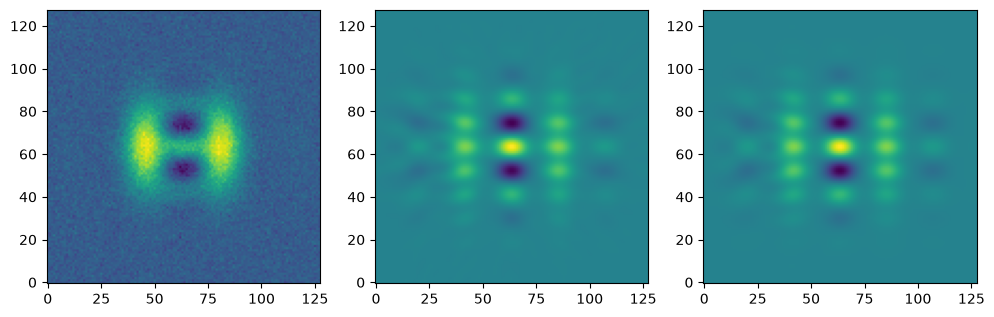

In [6]:
randint = np.random.randint(N)

model.eval()
with torch.no_grad():
    W_noisy = wigners[randint]
    w = torch.from_numpy(W_noisy)
    w = torch.unsqueeze(w, 0)
    w = torch.unsqueeze(w, 0)

    pred = model(w)
    rho_hat = rho_from_params(pred, N=64)
    rho_hat = qt.Qobj(rho_hat.squeeze(0))
    W_rec = apply_wigner(rho_hat, grid=128, xvec=5.0) # grid i xvec z config
    
    W_clean = wigners_clean[randint]
    
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(W_noisy, origin="lower")
axes[1].imshow(W_rec, origin="lower")
axes[2].imshow(W_clean, origin="lower")
plt.show()